In [10]:
import os
import sys
import zipfile
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split



In [11]:
# ====================== DOWNLOAD MOVIELENS 1M ======================
def download_movielens():
    url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
    zip_path = "ml-1m.zip"
    extract_path = "ml-1m"
    
    if not os.path.exists(extract_path):
        print("Downloading MovieLens 1M dataset...")
        r = requests.get(url, stream=True)
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        
        print("Extracting...")
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(".")
        os.remove(zip_path)
        print("Download complete!")
    else:
        print("MovieLens 1M already downloaded.")

download_movielens()



MovieLens 1M already downloaded.


In [12]:
# ====================== LOAD & PREPROCESS ======================
ratings = pd.read_csv(
    "ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=["userId", "movieId", "rating", "timestamp"]
)

# ====================== Custom Dataset ======================

TTE_ids = pd.read_json(f"TTE_user_split_uf90.json")

def no_diplicate_films(tp, columns):
  film_list = []
  for c in columns:
    for m_list in tp[c]:
      for m in m_list:
        film_list.append(m)
  return list(dict.fromkeys(film_list))

def filter_triplets(tp):
    usercount = len(tp)
    film_list = []
    itemcount = len(no_diplicate_films(tp, ['train_h', 'train_c', 'train_n', 'test_h', 'test_c', 'test_n', 'eval_h', 'eval_c', 'eval_n']))
    return tp, usercount, itemcount

TTE_ids , user_activity, item_popularity = filter_triplets(TTE_ids)
print(user_activity, item_popularity)

tr_users = TTE_ids['user_id']
#te_users = TTE_ids['user_id']

#tr_films = no_diplicate_films(TTE_ids, ['train_h', 'train_c', 'test_h', 'test_c'])
#te_films = no_diplicate_films(TTE_ids, ['eval_h', 'eval_c'])
all_films = no_diplicate_films(TTE_ids, ['train_h', 'train_c', 'train_n', 'test_h', 'test_c', 'test_n', 'eval_h', 'eval_c', 'eval_n'])

"""
train_plays = ratings.loc[ratings['userId'].isin(tr_users)]
train_plays = train_plays.loc[train_plays['movieId'].isin(tr_films)]

test_plays = ratings.loc[ratings['userId'].isin(te_users)]
test_plays = test_plays.loc[test_plays['movieId'].isin(te_films)]
"""

train_input_plays = pd.DataFrame()
valid_input_plays = pd.DataFrame()
test_input_plays = pd.DataFrame()

train_input_neg_plays = pd.DataFrame()
valid_input_neg_plays = pd.DataFrame()
test_input_neg_plays = pd.DataFrame()

train_output_plays = pd.DataFrame()
valid_output_plays = pd.DataFrame()
test_output_plays = pd.DataFrame()

for idx, row in TTE_ids.iterrows():
    user_films = ratings.loc[ratings['userId'].isin([row['user_id']])]
    for c in ['train_h', 'train_c', 'test_h', 'test_c', 'eval_h', 'eval_c']:
        user_tr = user_films.loc[user_films['movieId'].isin(row[c])]
        match c:
            case 'train_h':
                train_input_plays = pd.concat([train_input_plays, user_tr], ignore_index=True)
            case 'train_n':
                train_input_neg_plays = pd.concat([train_input_neg_plays, user_tr], ignore_index=True)
            case 'train_c':
                train_output_plays = pd.concat([train_output_plays, user_tr], ignore_index=True)
            case 'test_h':
                valid_input_plays = pd.concat([valid_input_plays, user_tr], ignore_index=True)
            case 'test_n':
                valid_input_neg_plays = pd.concat([valid_input_neg_plays, user_tr], ignore_index=True)
            case 'test_c':
                valid_output_plays = pd.concat([valid_output_plays, user_tr], ignore_index=True)
            case 'eval_h':
                test_input_plays = pd.concat([test_input_plays, user_tr], ignore_index=True)
            case 'eval_n':
                test_input_neg_plays = pd.concat([test_input_neg_plays, user_tr], ignore_index=True)
            case 'eval_c':
                test_output_plays = pd.concat([test_output_plays, user_tr], ignore_index=True)

print(len(train_input_plays))
print(len(test_output_plays))

user_ids = tr_users
movie_ids = all_films
user_map = {uid: idx for idx, uid in enumerate(user_ids)}
movie_map = {mid: idx for idx, mid in enumerate(movie_ids)}

n_users = len(user_ids)
n_items = len(movie_ids)
print(f"Users: {n_users}, Items: {n_items}")

# ====================== Matrix Dataset ======================

# Build interaction matrix (dense is fine for ML-1M: ~6k x 3.7k)
def build_input_matrix(hist_plays, c_plays, n_plays):
    interactions = np.zeros((n_users, n_items), dtype=np.float32) -1
    print()
    for n_iter, row in hist_plays.iterrows():
        if row["userId"] in user_map.keys() and row["movieId"] in movie_map.keys():
            u = user_map[row["userId"]]
            i = movie_map[row["movieId"]]
            interactions[u, i] = 1.0
    for n_iter, row in c_plays.iterrows():
        if row["userId"] in user_map.keys() and row["movieId"] in movie_map.keys():
            u = user_map[row["userId"]]
            i = movie_map[row["movieId"]]
            interactions[u, i] = 0.0
    for n_iter, row in n_plays.iterrows():
        if row["userId"] in user_map.keys() and row["movieId"] in movie_map.keys():
            u = user_map[row["userId"]]
            i = movie_map[row["movieId"]]
            interactions[u, i] = 0.0
    
    return interactions

def build_output_matrix(plays):
    interactions = np.zeros((n_users, n_items), dtype=np.float32)
    print()
    for n_iter, row in plays.iterrows():
        if row["userId"] in user_map.keys() and row["movieId"] in movie_map.keys():
            u = user_map[row["userId"]]
            i = movie_map[row["movieId"]]
            interactions[u, i] = 1.0
    
    return interactions

"""
interactions_te = np.zeros((n_users, n_items), dtype=np.float32)
print()
for n_iter, row in test_plays.iterrows():
    if n_iter%100 == 0:
        sys.stdout.write(f"\rTest Iter: {n_iter}/{len(test_plays)}")
        sys.stdout.flush()
    if row["userId"] in user_map.keys() and row["movieId"] in te_films:
        u = user_map[row["userId"]]
        i = movie_map[row["movieId"]]
        interactions_te[u, i] = 1.0
"""

train_matrix_i = build_input_matrix(train_input_plays, train_output_plays, train_input_neg_plays)
train_matrix_o = build_output_matrix(train_output_plays)

valid_matrix_i = build_input_matrix(valid_input_plays, valid_output_plays, valid_input_neg_plays)
valid_matrix_o = build_output_matrix(valid_output_plays)

test_matrix_i = build_input_matrix(test_input_plays, test_output_plays, test_input_neg_plays)
test_matrix_o = build_output_matrix(test_output_plays)

print(len(train_matrix_i), len(train_matrix_i[0]))
print(train_matrix_i[0])


4430 3387
44300
44300
Users: 4430, Items: 3387






4430 3387
[ 1.  1.  1. ... -1. -1. -1.]


In [13]:
# ====================== DATASET ======================
class UserDataset(Dataset):
    def __init__(self, input_matrix, output_matrix):
        self.input_data  = torch.from_numpy(input_matrix).float()
        self.output_data = torch.from_numpy(output_matrix).float()
   
    def __len__(self):
        return len(self.input_data)
   
    def __getitem__(self, idx):
        return self.input_data[idx], self.output_data[idx]   # returns (input, target)

#train_dataset = UserDataset(train_matrix)
#train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)

train_dataset = UserDataset(train_matrix_i, train_matrix_o)
valid_dataset   = UserDataset(valid_matrix_i,   valid_matrix_o)
test_dataset  = UserDataset(test_matrix_i,  test_matrix_o)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_dataset,   batch_size=512, shuffle=False, num_workers=2)

In [14]:
# ====================== MULT-VAE MODEL ======================
class MultVAE(nn.Module):
    def __init__(self, n_items, hidden_dim=400, latent_dim=100, dropout=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_items, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout)
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_items)
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultVAE(n_items).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=0.0)



In [15]:
# ====================== LOSS (Multinomial + KL) ======================
def mult_vae_loss(logits, target, mu, logvar, anneal=1.0):
    # Reconstruction: negative multinomial log-likelihood
    log_softmax = torch.log_softmax(logits, dim=1)
    recon_loss = -torch.sum(target * log_softmax, dim=1)
    
    # KL divergence (standard Gaussian prior)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    
    return torch.mean(recon_loss + anneal * kl_loss)



In [16]:
# ====================== TRAINING ======================
epochs = 100
anneal_steps = 20  # gradually increase KL weight
best_loss = float("inf")
best_val_loss = float("inf")
patience = 10          # early stopping patience
counter = 0

train_loss_history = []
valid_loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    anneal = min(1.0, (epoch + 1) / anneal_steps)  # simple linear annealing
    
    for input_batch, output_batch in train_loader:
        input_batch  = input_batch.to(device)
        output_batch = output_batch.to(device)
        
        optimizer.zero_grad()
        logits, mu, logvar = model(input_batch)
        loss = mult_vae_loss(logits, output_batch, mu, logvar, anneal)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # stability
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_train_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_batch, output_batch in valid_loader:
            input_batch  = input_batch.to(device)
            output_batch = output_batch.to(device)
            logits, mu, logvar = model(input_batch)
            loss = mult_vae_loss(logits, output_batch, mu, logvar, anneal)
            val_loss += loss.item()
   
    avg_val_loss = val_loss / len(valid_loader)
    valid_loss_history.append(avg_val_loss)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Anneal: {anneal:.2f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "multvae_movielens.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

print("Training finished! Model saved as multvae_movielens.pth")



Epoch  1/100 | Train Loss: 82.3897 | Val Loss: 81.0488 | Anneal: 0.05
Epoch  2/100 | Train Loss: 81.9416 | Val Loss: 79.7784 | Anneal: 0.10
Epoch  3/100 | Train Loss: 80.6656 | Val Loss: 78.3268 | Anneal: 0.15
Epoch  4/100 | Train Loss: 79.1826 | Val Loss: 77.3649 | Anneal: 0.20
Epoch  5/100 | Train Loss: 78.3290 | Val Loss: 77.0839 | Anneal: 0.25
Epoch  6/100 | Train Loss: 77.9414 | Val Loss: 76.8949 | Anneal: 0.30
Epoch  7/100 | Train Loss: 77.6959 | Val Loss: 76.7298 | Anneal: 0.35
Epoch  8/100 | Train Loss: 77.6155 | Val Loss: 76.8762 | Anneal: 0.40
Epoch  9/100 | Train Loss: 77.5421 | Val Loss: 76.7260 | Anneal: 0.45
Epoch 10/100 | Train Loss: 77.4970 | Val Loss: 77.0663 | Anneal: 0.50
Epoch 11/100 | Train Loss: 77.4937 | Val Loss: 76.7230 | Anneal: 0.55
Epoch 12/100 | Train Loss: 77.3053 | Val Loss: 76.6667 | Anneal: 0.60
Epoch 13/100 | Train Loss: 77.2800 | Val Loss: 76.6910 | Anneal: 0.65
Epoch 14/100 | Train Loss: 77.1084 | Val Loss: 76.8634 | Anneal: 0.70
Epoch 15/100 | Train

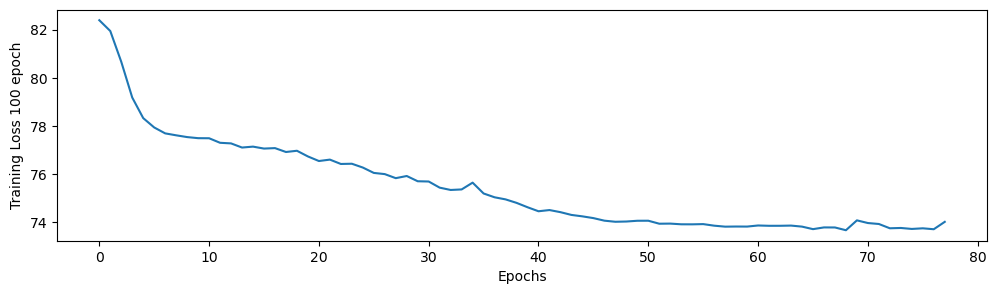

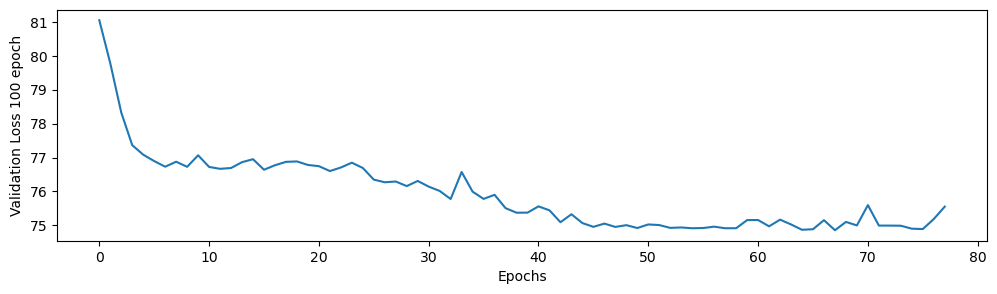

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(12, 3))
plt.plot(train_loss_history)
#plt.plot(loss_hist)
plt.ylabel(f"Training Loss {epochs} epoch")
plt.xlabel("Epochs")
pass

plt.figure(figsize=(12, 3))
plt.plot(valid_loss_history)
#plt.plot(loss_hist)
plt.ylabel(f"Validation Loss {epochs} epoch")
plt.xlabel("Epochs")
pass

In [21]:
# ====================== RECOMMENDATION FUNCTION ======================
def recommend_for_user(model, user_idx, train_interactions, k=10):
    model.eval()
    with torch.no_grad():
        user_vec = torch.tensor(train_interactions[user_idx]).unsqueeze(0).float().to(device)
        logits, _, _ = model(user_vec)
        scores = logits.squeeze().cpu().numpy()
        
        # Mask already seen items
        seen = train_interactions[user_idx] > 0
        scores[seen] = -np.inf
        
        top_k_idx = np.argsort(scores)[-k:][::-1]
        return top_k_idx

# Load movie titles for nice output
movies = pd.read_csv(
    "ml-1m/movies.dat",
    sep="::",
    engine="python",
    names=["movieId", "title", "genres"],
    encoding="ISO-8859-1"
)
movie_title_map = {}
for _, row in movies.iterrows():
    if row["movieId"] in movie_map:
        movie_title_map[movie_map[row["movieId"]]] = row["title"]

# Example recommendation for user 0 (change user_idx as you like)
user_idx = 0
top_movies_idx = recommend_for_user(model, user_idx, test_matrix_i, k=10)
print("\n=== Recommended movies for user", user_idx, "===")
for rank, item_idx in enumerate(top_movies_idx, 1):
    title = movie_title_map.get(item_idx, f"Unknown (ID {item_idx})")
    print(f"{rank}. {title}")




=== Recommended movies for user 0 ===
1. Men in Black (1997)
2. Fargo (1996)
3. Matrix, The (1999)
4. Ghostbusters (1984)
5. Groundhog Day (1993)
6. Usual Suspects, The (1995)
7. Total Recall (1990)
8. Jurassic Park (1993)
9. Forrest Gump (1994)
10. Gladiator (2000)


In [28]:
test_dict = {}
reverse_movie_map = {idx: mid for mid, idx in movie_map.items()}
reverse_user_map = {idx: uid for uid, idx in user_map.items()}
for user_idx in range(len(test_matrix_i)):
    top_movies_idx = recommend_for_user(model, user_idx, test_matrix_i, k=10)
    movie_rank = []
    for m_i, movie in enumerate(top_movies_idx):
      if m_i < 10:
        movie_rank.append({
            "item": reverse_movie_map[movie],
            "score": 1
        })
    test_dict[f"user{reverse_user_map[user_idx]}"] = movie_rank

def elliotize_data(recs_dict, recs_tsv_path):
  data = []
  for user_id, rec_list in recs_dict.items():
      for rec in rec_list:
          item_id = rec["item"]
          score = float(rec["score"])
          data.append([str(user_id), str(item_id), score])

  # Create DataFrame and ensure sorting per user (score descending)
  df_recs = pd.DataFrame(data, columns=["user", "item", "score"])
  df_recs = df_recs.sort_values(by=["user", "score"], ascending=[True, False])

  #recs_tsv_path = "my_recommendations.tsv"
  df_recs.to_csv(recs_tsv_path, sep="\t", header=False, index=False)
  print(f"Recommendations saved to {recs_tsv_path} (format: user\titem\tscore)")


elliotize_data(test_dict, f"MultiVAE_naturals_elliot.tsv")

Recommendations saved to MultiVAE_naturals_elliot.tsv (format: user	item	score)


In [ ]:
print("Based on the user's watching history and the film's rating, order the list of candidate films. Order the films where the first one of the list is the most likely to be watched by the user. The output should only contain the ordered list of the recommended films bounded by the  special strings '%% START RECOMMENDED LIST %%' and '%% END LIST %%'. Here follows the user's history and the list of candidate films.\n%% START HISTORY %%\nMovie name: Toy Story 2 (1999)\tRating:4\nMovie name: Airplane! (1980)\tRating:4\nMovie name: Pleasantville (1998)\tRating:3\nMovie name: Dumbo (1941)\tRating:5\nMovie name: Princess Bride, The (1987)\tRating:3\nMovie name: Snow White and the Seven Dwarfs (1937)\tRating:4\nMovie name: Miracle on 34th Street (1947)\tRating:4\nMovie name: Ponette (1996)\tRating:4\nMovie name: Schindler's List (1993)\tRating:5\nMovie name: Aladdin (1992)\tRating:4\n%% END HISTORY %%\n%% START CANDIDATES %%\nMovie name: 13th Warrior, The (1999)\nMovie name: Dogma (1999)\nMovie name: Unforgiven (1992)\nMovie name: Dirty Dozen, The (1967)\nMovie name: Gladiator (2000)\nMovie name: Firm, The (1993)\nMovie name: Sling Blade (1996)\nMovie name: Fight Club (1999)\nMovie name: Simple Plan, A (1998)\nMovie name: Addams Family, The (1991)\nMovie name: Caddyshack (1980)\nMovie name: Star Trek III: The Search for Spock (1984)\nMovie name: Breakfast Club, The (1985)\nMovie name: Dark City (1998)\nMovie name: Jackie Brown (1997)\nMovie name: Shining, The (1980)\nMovie name: Terminator, The (1984)\nMovie name: Lost World: Jurassic Park, The (1997)\nMovie name: Blair Witch Project, The (1999)\nMovie name: Heat (1995)\nMovie name: Beauty and the Beast (1991)\nMovie name: Crocodile Dundee (1986)\nMovie name: What About Bob? (1991)\nMovie name: Rocketeer, The (1991)\nMovie name: Batman (1989)\nMovie name: When Harry Met Sally... (1989)\nMovie name: Blazing Saddles (1974)\nMovie name: Apocalypse Now (1979)\nMovie name: Air Force One (1997)\nMovie name: Star Trek: The Wrath of Khan (1982)\nMovie name: Edward Scissorhands (1990)\nMovie name: Meet the Parents (2000)\nMovie name: Deep Impact (1998)\nMovie name: Mad Max 2 (a.k.a. The Road Warrior) (1981)\nMovie name: Bull Durham (1988)\nMovie name: Star Trek IV: The Voyage Home (1986)\nMovie name: Witness (1985)\nMovie name: Goonies, The (1985)\nMovie name: Basic Instinct (1992)\nMovie name: Manchurian Candidate, The (1962)\nMovie name: Talented Mr. Ripley, The (1999)\nMovie name: As Good As It Gets (1997)\nMovie name: Mummy, The (1999)\nMovie name: True Lies (1994)\nMovie name: Robocop (1987)\nMovie name: Batman Returns (1992)\nMovie name: My Best Friend's Wedding (1997)\nMovie name: Parenthood (1989)\nMovie name: Clockwork Orange, A (1971)\nMovie name: Almost Famous (2000)\nMovie name: Scream (1996)\nMovie name: Repo Man (1984)\nMovie name: Wrong Trousers, The (1993)\nMovie name: Hercules (1997)\nMovie name: Gremlins (1984)\nMovie name: Good Will Hunting (1997)\nMovie name: Citizen Kane (1941)\nMovie name: League of Their Own, A (1992)\nMovie name: Toy Story (1995)\nMovie name: Payback (1999)\nMovie name: Amadeus (1984)\nMovie name: Player, The (1992)\nMovie name: Shakespeare in Love (1998)\nMovie name: Grease (1978)\nMovie name: Hunt for Red October, The (1990)\nMovie name: Dog Day Afternoon (1975)\nMovie name: Tarzan (1999)\nMovie name: Back to the Future Part II (1989)\nMovie name: Pocahontas (1995)\nMovie name: Close Encounters of the Third Kind (1977)\nMovie name: Poltergeist (1982)\nMovie name: Fish Called Wanda, A (1988)\nMovie name: Dune (1984)\nMovie name: Splash (1984)\nMovie name: Hunchback of Notre Dame, The (1996)\nMovie name: Patriot, The (2000)\nMovie name: From Dusk Till Dawn (1996)\nMovie name: Big Chill, The (1983)\nMovie name: Fatal Attraction (1987)\nMovie name: Taxi Driver (1976)\nMovie name: Godfather: Part II, The (1974)\nMovie name: Alien (1979)\nMovie name: GoldenEye (1995)\nMovie name: Nightmare Before Christmas, The (1993)\nMovie name: Twister (1996)\nMovie name: Tomorrow Never Dies (1997)\nMovie name: Grifters, The (1990)\nMovie name: Antz (1998)\nMovie name: Cocoon (1985)\nMovie name: Entrapment (1999)\nMovie name: Bug's Life, A (1998)\nMovie name: Dave (1993)\nMovie name: L.A. Story (1991)\nMovie name: Little Shop of Horrors (1986)\nMovie name: Mulan (1998)\nMovie name: Go (1999)\nMovie name: Close Shave, A (1995)\nMovie name: You've Got Mail (1998)\nMovie name: Leaving Las Vegas (1995)\nMovie name: Star Trek: The Motion Picture (1979)\n%% END CANDIDATES %%\n\n\n%% START RECOMMENDED LIST %%\nMovie name: Pocahontas (1995)\nMovie name: Bug's Life, A (1998)\nMovie name: Beauty and the Beast (1991)\nMovie name: Toy Story (1995)\nMovie name: Hercules (1997)\nMovie name: Mulan (1998)\nMovie name: Antz (1998)\nMovie name: Hunchback of Notre Dame, The (1996)\nMovie name: Tarzan (1999)\nMovie name: Close Shave, A (1995)\nMovie name: Heat (1995)\nMovie name: GoldenEye (1995)\nMovie name: Leaving Las Vegas (1995)\nMovie name: From Dusk Till Dawn (1996)\nMovie name: Taxi Driver (1976)\nMovie name: True Lies (1994)\nMovie name: Dave (1993)\nMovie name: Firm, The (1993)\nMovie name: Nightmare Before Christmas, The (1993)\nMovie name: Batman (1989)\nMovie name: Alien (1979)\nMovie name: Citizen Kane (1941)\nMovie name: Hunchback of Notre Dame, The (1996)\nMovie name: Clockwork Orange, A (1971)\nMovie name: Scream (1996)\nMovie name: Twister (1996)\nMovie name: Basic Instinct (1992)\nMovie name: When Harry Met Sally... (1989)\nMovie name: Grifters, The (1990)\nMovie name: Fish Called Wanda, A (1988)\nMovie name: Wrong Trousers, The (1993)\nMovie name: Terminator, The (1984)\nMovie name: Shining, The (1980)\nMovie name: Unforgiven (1992)\nMovie name: Manchurian Candidate, The (1962)\nMovie name: Apocalypse Now (1979)\nMovie name: Blazing Saddles (1974)\nMovie name: Star Trek III: The Search for Spock (1984)\nMovie name: Firm, The (1993)\nMovie name: Basic Instinct (1992)\nMovie name: Batman Returns (1992)\nMovie name: Firm, The (1993)\nMovie name: As Good As It Gets (1997)\nMovie name: Clockwork Orange, A (1971)\nMovie name: Sling Blade (1996)\nMovie name: Wrong Trousers, The (1993)\nMovie name: Wrong Trousers, The (")


In [24]:
# ====================== SIMPLE EVALUATION (Recall@10 & NDCG@10) ======================
@torch.no_grad()
def evaluate(model, test_input, test_output, k=10):
    model.eval()
    recalls = []
    ndcgs = []
    
    for u in range(n_users):
        if np.sum(test_input[u]) == 0:
            continue
            
        user_vec = torch.tensor(test_input[u]).unsqueeze(0).float().to(device)
        logits = model(user_vec)[0].squeeze().cpu().numpy()
        
        # Mask train items
        scores = logits.copy()
        scores[test_input[u] > 0] = -np.inf
        
        ranked = np.argsort(scores)[::-1]
        true_items = set(np.where(test_output[u] > 0)[0])
        
        # Recall@K
        hits = len(set(ranked[:k]) & true_items)
        recall = hits / len(true_items)
        recalls.append(recall)
        
        # NDCG@K
        dcg = sum(1 / np.log2(i + 2) for i, item in enumerate(ranked[:k]) if item in true_items)
        idcg = sum(1 / np.log2(i + 2) for i in range(min(k, len(true_items))))
        ndcg = dcg / idcg if idcg > 0 else 0
        ndcgs.append(ndcg)
    
    return np.mean(recalls), np.mean(ndcgs)

rec, ndcg = evaluate(model, test_matrix_i, test_matrix_o, k=10)
print(f"\nEvaluation on held-out test set:")
print(f"Recall@10: {rec:.4f}")
print(f"NDCG@10 : {ndcg:.4f}")


Evaluation on held-out test set:
Recall@10: 0.0217
NDCG@10 : 0.0222
